**Goal:** close Unit VI with the clustering family for **elliptical, overlapping** groups. You will
fit a **Gaussian Mixture Model**, read its **soft** assignments (`predict_proba` -- a probability per
cluster, not one hard label), and watch it recover tilted clusters that K-Means slices straight
across (ARI 0.291 -> 0.961). Then you will **open the EM box** by coding Expectation-Maximization by
hand on a 1-D mixture, choose the number of components with **BIC/AIC**, and finish with a bake-off
that places GMM next to K-Means and DBSCAN. Pairs with the concept note
[Gaussian Mixtures & the EM Algorithm](l25_concept_gaussian_mixtures_em.qmd).

> **Previously:** L24 -- Hierarchical & Density-Based Clustering  |  **Next:** L26 -- Principal Component Analysis

> This page is the read-only view. To run the lab, open the notebook
> (`l25_lab_gaussian_mixtures_em.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

Our data is a **mixture of three Gaussians**: two long, tilted blobs that overlap, plus one compact
round blob. It is synthetic (a fixed seed, identical for everyone) and 2-D so every clustering is
plottable. The shape is the point -- the clusters are genuine Gaussians, but **stretched and
rotated**, exactly the case K-Means' round-blob assumption gets wrong. ARI (the Adjusted Rand Index)
is again our yardstick against the known truth: 1.0 is perfect, 0 is random.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second
imports, seeds, and builds the mixture.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, scipy, numpy and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn scipy
# local, in a terminal (not in the notebook):  uv add scikit-learn scipy numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from scipy.stats import norm

# Two elongated, tilted Gaussian blobs (rotated by a 2x2 matrix) + one compact round blob.
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))      # stretch + rotate -> tilted ellipses
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2 + 2]                                       # 3 true components: 0, 1, 2
print("mixture:", X.shape, "-- true component sizes:", np.bincount(y))

mixture: (1250, 2) -- true component sizes: [500 500 250]


~~~text
mixture: (1250, 2) -- true component sizes: [500 500 250]
~~~

## Step 1: Soft Clustering -- a Probability per Cluster

K-Means and DBSCAN each gave you one **hard** label per point. A **Gaussian Mixture Model** fits the
data as a weighted sum of K Gaussians and hands back, for every point, a **responsibility**: the
probability that it belongs to each component. Fit one with three components and look at what comes
out -- `predict` gives the hard label, `predict_proba` gives the soft probabilities:

In [3]:
gm = GaussianMixture(n_components=3, n_init=10, random_state=42).fit(X)
print(f"GMM converged: {gm.converged_} in {gm.n_iter_} iterations")
print("mixture weights:", [round(float(w), 2) for w in gm.weights_])

proba = gm.predict_proba(X)
soft = int((proba.max(axis=1) < 0.95).sum())
print(f"{soft} of {len(X)} points are genuinely soft (no component is >= 95% sure)")

i = proba.max(axis=1).argmin()                              # the single most-uncertain point
print("most-uncertain point, predict_proba:", [round(float(p), 3) for p in proba[i]],
      "-> hard label", gm.predict(X)[i])

GMM converged: True in 4 iterations
mixture weights: [0.4, 0.21, 0.39]
103 of 1250 points are genuinely soft (no component is >= 95% sure)
most-uncertain point, predict_proba: [0.0, 0.494, 0.506] -> hard label 2


~~~text
GMM converged: True in 4 iterations
mixture weights: [0.4, 0.21, 0.39]
103 of 1250 points are genuinely soft (no component is >= 95% sure)
most-uncertain point, predict_proba: [0.0, 0.494, 0.506] -> hard label 2
~~~

That most-uncertain point is essentially a coin flip -- **49.4% vs 50.6%** between two clusters --
and a hard label throws that nuance away. 103 points sit in the overlap where the answer is genuinely
"a bit of both." Colour the scatter by the GMM's hard label to see the three groups it found:

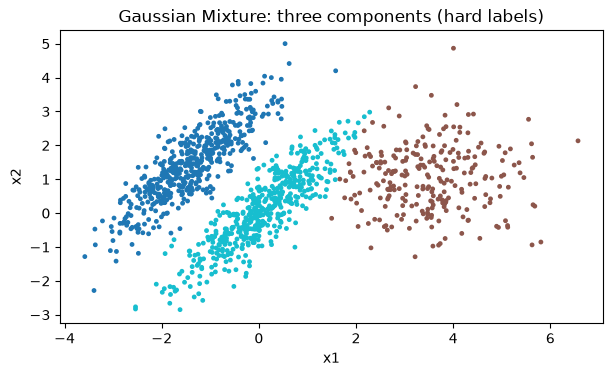

In [4]:
plt.figure(figsize=(7, 3.8))
plt.scatter(X[:, 0], X[:, 1], c=gm.predict(X), s=6, cmap="tab10")
plt.title("Gaussian Mixture: three components (hard labels)")
plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

The three tilted ellipses come out cleanly separated even where they overlap -- and the 103 soft,
uncertain points all live in that overlap band between neighbouring clusters, where the hard label is
least trustworthy.

A fitted GMM is also **generative**: because it is a full probability model of the data, it can
*invent* new points with `sample`, and score how *typical* any point is with `score_samples` (the
log-density). Low density means "unlike the training data" -- free anomaly detection:

In [5]:
new_points, new_labels = gm.sample(5)
print("5 newly sampled points came from components:", new_labels)
print(f"densest training point, log-density: {gm.score_samples(X).max():.2f}")
print(f"a point far outside every cluster [12, 12]: {gm.score_samples([[12, 12]])[0]:.2f}")

5 newly sampled points came from components: [0 0 1 1 2]
densest training point, log-density: -1.96
a point far outside every cluster [12, 12]: -100.95


~~~text
5 newly sampled points came from components: [0 0 1 1 2]
densest training point, log-density: -1.96
a point far outside every cluster [12, 12]: -100.95
~~~

## Step 2: Open the Box -- EM by Hand

Where do those Gaussians come from? **Expectation-Maximization**. It is a chicken-and-egg loop: if
you knew which point belonged to which Gaussian you could fit the Gaussians, and if you knew the
Gaussians you could assign the points -- so EM alternates. The **E-step** computes responsibilities
from the current parameters; the **M-step** re-fits each Gaussian's mean, spread, and weight,
*weighted by* those responsibilities. Repeat until nothing moves. Code it on a 1-D mixture of two
Gaussians (true means 3 and 10, stds 2 and 3) so the whole loop is visible:

In [6]:
# The 1-D data: two Gaussians stacked. EM does not get to see which point came from which.
rng = np.random.RandomState(42)
data = np.concatenate([rng.normal(3.0, 2.0, 5000), rng.normal(10.0, 3.0, 5000)])
print("1-D mixture:", data.shape, "-- true means 3 / 10, stds 2 / 3, weight 0.5")

1-D mixture: (10000,) -- true means 3 / 10, stds 2 / 3, weight 0.5


~~~text
1-D mixture: (10000,) -- true means 3 / 10, stds 2 / 3, weight 0.5
~~~

In [7]:
# Uncomment and complete the E-step normalization, then run the EM loop.
# m1, m2, s1, s2, w = 0.0, 15.0, 1.0, 1.0, 0.4               # a deliberately-wrong starting guess
# for it in range(1, 1001):
#     # E-step: each component's weighted likelihood, normalized so the responsibilities sum to 1
#     L1 = w * norm.pdf(data, m1, s1)
#     L2 = (1 - w) * norm.pdf(data, m2, s2)
#     r1 = L1 / (____)                                       # <- normalize so r1 + r2 = 1
#     old = (m1, m2, s1, s2, w)
#     # M-step: re-fit each Gaussian, weighted by its responsibilities
#     m1 = np.sum(r1 * data) / np.sum(r1)
#     m2 = np.sum((1 - r1) * data) / np.sum(1 - r1)
#     s1 = np.sqrt(np.sum(r1 * (data - m1) ** 2) / np.sum(r1))
#     s2 = np.sqrt(np.sum((1 - r1) * (data - m2) ** 2) / np.sum(1 - r1))
#     w = np.mean(r1)
#     if max(abs(a - b) for a, b in zip((m1, m2, s1, s2, w), old)) < 1e-6:
#         break
# print(f"EM converged in {it} iterations from a wrong start")
# print(f"  component 1: mean {m1:.3f}, std {s1:.3f}   (true 3.0, 2.0)")
# print(f"  component 2: mean {m2:.3f}, std {s2:.3f}   (true 10.0, 3.0)")
# print(f"  mixture weight w: {w:.3f}   (true 0.5)")

<details><summary>Expected Output</summary>

~~~text
EM converged in 182 iterations from a wrong start
  component 1: mean 3.019, std 2.000   (true 3.0, 2.0)
  component 2: mean 9.966, std 3.041   (true 10.0, 3.0)
  mixture weight w: 0.500   (true 0.5)
~~~

The blank is `r1 = L1 / (L1 + L2)` -- divide each component's weighted likelihood by their sum so the
two responsibilities add to 1. From a wrong start (means 0 and 15), EM climbs back to the truth in
182 iterations: means 3.019 / 9.966, stds 2.000 / 3.041, weight 0.500. Each M-step is just a
**weighted** mean and variance, where the weights are the responsibilities -- soft assignments, not
hard ones. That is the entire algorithm.
</details>

Now confirm scikit-learn's `GaussianMixture` runs this exact loop internally -- fit it on the same
1-D data and you get the same parameters:

In [8]:
gm1d = GaussianMixture(n_components=2, max_iter=1000, tol=1e-6, random_state=42).fit(data.reshape(-1, 1))
order = np.argsort(gm1d.means_.flatten())
print("sklearn GaussianMixture on the same data:")
print("  means:  ", gm1d.means_.flatten()[order].round(3))
print("  stds:   ", np.sqrt(gm1d.covariances_.flatten())[order].round(3))
print("  weights:", gm1d.weights_[order].round(3))

sklearn GaussianMixture on the same data:
  means:   [ 3.037 10.001]
  stds:    [2.009 3.021]
  weights: [0.504 0.496]


~~~text
sklearn GaussianMixture on the same data:
  means:   [ 3.037 10.001]
  stds:    [2.009 3.021]
  weights: [0.504 0.496]
~~~

Same answer, to two decimals. `GaussianMixture.fit()` is EM with a faster, vectorized inner loop and
a `n_init` that runs it several times (because, like K-Means, EM only finds a **local** maximum and a
bad start can converge to a worse one).

## Step 3: The Payoff -- Tilted Ellipses K-Means Cuts Across

Back to the 2-D mixture. K-Means assigns every point to its nearest centroid, which draws straight
(Voronoi) borders -- fine for round blobs, wrong for tilted ellipses, because a long cluster's far
end is closer to a *neighbor's* centroid. GMM fits a full **covariance** per component, so each
cluster is an ellipse of any orientation. Score them head to head on the same data:

In [9]:
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
print(f"K-Means ARI:   {adjusted_rand_score(y, km.labels_):.3f}")
print(f"GMM(full) ARI: {adjusted_rand_score(y, gm.predict(X)):.3f}")

K-Means ARI:   0.291
GMM(full) ARI: 0.961


~~~text
K-Means ARI:   0.291
GMM(full) ARI: 0.961
~~~

A near-total reversal -- 0.291 to 0.961 -- on data that is *made of Gaussians*. Plot both labelings
side by side and the reason is obvious: K-Means carves the overlap region with a straight line, while
GMM bends its boundaries to follow the tilted ellipses.

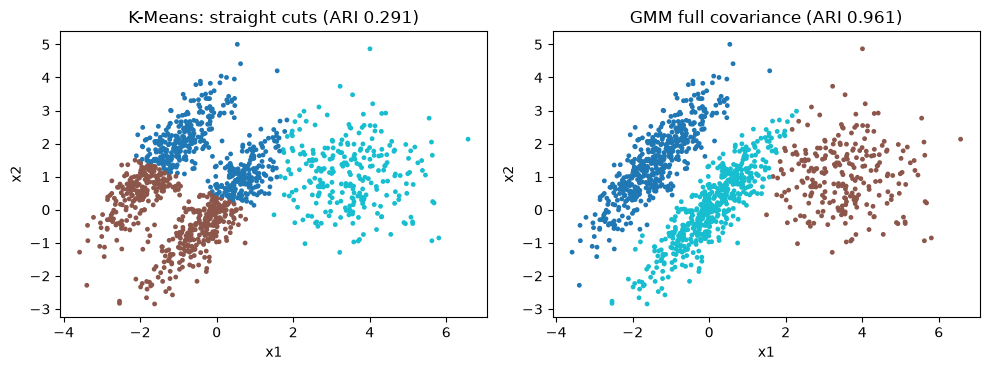

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].scatter(X[:, 0], X[:, 1], c=km.labels_, s=6, cmap="tab10")
ax[0].set_title(f"K-Means: straight cuts (ARI {adjusted_rand_score(y, km.labels_):.3f})")
ax[1].scatter(X[:, 0], X[:, 1], c=gm.predict(X), s=6, cmap="tab10")
ax[1].set_title(f"GMM full covariance (ARI {adjusted_rand_score(y, gm.predict(X)):.3f})")
for a in ax:
    a.set_xlabel("x1"); a.set_ylabel("x2")
plt.tight_layout(); plt.show()

## Step 4: Choosing k, and the Three-Way Bake-Off

You cannot use the elbow or silhouette here -- both assume round clusters, and ours are ellipses.
GMM brings its own model-selection tools: **BIC** and **AIC**, information criteria that reward a
good fit and penalize extra parameters. Lower is better; the dip marks the best `k`:

In [11]:
# Uncomment and complete: sweep n_components and let BIC/AIC pick k.
# for k in (____, ____, ____, ____, ____, ____):             # try k = 1..6
#     g = GaussianMixture(n_components=k, n_init=10, random_state=42).fit(X)
#     print(f"  k={k}: BIC {g.bic(X):8.1f}   AIC {g.aic(X):8.1f}")

<details><summary>Expected Output</summary>

~~~text
  k=1: BIC   9330.4   AIC   9304.8
  k=2: BIC   8971.2   AIC   8914.8
  k=3: BIC   8189.7   AIC   8102.5
  k=4: BIC   8229.6   AIC   8111.6
  k=5: BIC   8273.9   AIC   8125.1
  k=6: BIC   8312.0   AIC   8132.4
~~~

The blank is `for k in (1, 2, 3, 4, 5, 6):`. Both BIC and AIC bottom out at **k=3** -- the true
number of components -- then rise as extra Gaussians buy fit that is not worth the parameters. BIC
penalizes complexity harder than AIC, so on larger data it tends to pick the simpler model; here they
agree.
</details>

Finally, put all three of Unit VI's algorithms on two shapes -- our elliptical Gaussians and L24's
moons -- to see that **the winner is decided by the structure, not the algorithm's effort**:

In [12]:
Xm, ym = make_moons(n_samples=1000, noise=0.05, random_state=42)
km_m = KMeans(n_clusters=2, n_init=10, random_state=42).fit(Xm)
gm_m = GaussianMixture(n_components=2, n_init=10, random_state=42).fit(Xm)
db_m = DBSCAN(eps=0.15, min_samples=5).fit(Xm)
print("ELLIPTICAL Gaussians (this lab):")
print(f"  K-Means {adjusted_rand_score(y, km.labels_):.3f}  |  GMM {adjusted_rand_score(y, gm.predict(X)):.3f}")
print("MOONS (non-Gaussian crescents, from L24):")
print(f"  K-Means {adjusted_rand_score(ym, km_m.labels_):.3f}  |  "
      f"GMM {adjusted_rand_score(ym, gm_m.predict(Xm)):.3f}  |  "
      f"DBSCAN {adjusted_rand_score(ym, db_m.labels_):.3f}")

ELLIPTICAL Gaussians (this lab):
  K-Means 0.291  |  GMM 0.961
MOONS (non-Gaussian crescents, from L24):
  K-Means 0.239  |  GMM 0.501  |  DBSCAN 1.000


~~~text
ELLIPTICAL Gaussians (this lab):
  K-Means 0.291  |  GMM 0.961
MOONS (non-Gaussian crescents, from L24):
  K-Means 0.239  |  GMM 0.501  |  DBSCAN 1.000
~~~

GMM wins the ellipses (0.961) but **fails the moons** (0.501) -- because the moons are not Gaussians,
and GMM, like K-Means, assumes convex Gaussian-ish blobs. On the moons it is DBSCAN's connected
density that wins (1.000). No clusterer wins everywhere; the whole of Unit VI is **match the
algorithm to the structure of your data**.

## Your Turn

### Exercise 1 -- the covariance ladder

GMM's power on the ellipses came from `covariance_type="full"`. Tighten that constraint and the model
degrades toward K-Means. Fit `GaussianMixture(n_components=3)` on the same `X, y` with each
`covariance_type` and report the ARIs -- watch where the win comes from.

In [13]:
# TODO: for ct in ("spherical", "diag", "tied", "full"):
#           fit GaussianMixture(n_components=3, covariance_type=ct, n_init=10, random_state=42)
#           print ct and adjusted_rand_score(y, model.predict(X))

<details><summary>Expected Output</summary>

~~~text
  covariance_type=spherical  ARI 0.300
  covariance_type=diag       ARI 0.410
  covariance_type=tied       ARI 0.925
  covariance_type=full       ARI 0.961
~~~

`spherical` covariance forces round, axis-aligned blobs -- it scores **0.300**, essentially
K-Means' 0.291, because a spherical-equal-variance GMM *is* K-Means. Relaxing the constraint to
`diag` (axis-aligned ellipses), then `tied` (one shared ellipse shape), then `full` (any tilted
ellipse per cluster) climbs to **0.961**. The win was never "GMM magic" -- it was letting each
cluster be a tilted ellipse.
</details>

### Exercise 2 -- let BIC find k on fresh data

Here is a new dataset of four overlapping blobs, with the labels hidden from the model. Use BIC to
recover the number of components without being told it.

In [14]:
X_new, y_new = make_blobs(n_samples=600, centers=4, cluster_std=1.2, random_state=7)
print("fresh overlapping blobs:", X_new.shape, "-- true k = 4 (the model is not told)")

fresh overlapping blobs: (600, 2) -- true k = 4 (the model is not told)


~~~text
fresh overlapping blobs: (600, 2) -- true k = 4 (the model is not told)
~~~

**Hint:** loop `k` over 1..6, fit `GaussianMixture(n_components=k, n_init=10, random_state=42)` on
`X_new`, print `g.bic(X_new)` for each, and read off the `k` with the lowest BIC.

In [15]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
  k=1: BIC 7709.5
  k=2: BIC 6423.3
  k=3: BIC 5828.2
  k=4: BIC 5570.2
  k=5: BIC 5587.8
  k=6: BIC 5613.2
BIC picks k=4
~~~

BIC falls steeply through k=4, then turns back up at k=5 -- so it selects **k=4**, the true number of
blobs, with no labels and no elbow-eyeballing. This is the model-selection tool of choice for GMM,
where silhouette and inertia do not apply.
</details>

## Summary

- A **Gaussian Mixture Model** fits data as a weighted sum of K Gaussians and returns **soft**
  assignments -- `predict_proba` gives each point a probability per cluster (103 of our 1250 points
  were genuinely split, one of them a 49/51 coin flip), where K-Means and DBSCAN give one hard label.
- **Expectation-Maximization** fits it: the **E-step** computes responsibilities, the **M-step**
  re-fits each Gaussian weighted by them; by hand on a 1-D mixture it climbed from a wrong start back
  to the true means/stds/weight in 182 iterations, and scikit-learn's `GaussianMixture` matched it.
- With `covariance_type="full"`, GMM fits **tilted ellipses** and recovered clusters K-Means cut
  across -- **ARI 0.291 -> 0.961** on data made of Gaussians; the covariance ladder
  (spherical 0.300 ~ K-Means, up to full 0.961) shows K-Means is just GMM with spherical covariance.
- Choose the number of components with **BIC/AIC** (both dipped at the true k=3 / k=4), not the
  elbow or silhouette, which assume round clusters.
- The bake-off closes Unit VI: GMM owns **elliptical, overlapping** Gaussians (0.961) but fails the
  non-Gaussian moons (0.501), where DBSCAN's density wins (1.000). **Match the algorithm to the
  structure** -- centroids for round blobs, density/single-linkage for connected shapes, Gaussian
  mixtures for tilted, overlapping, soft clusters.
- Next (L26): we leave clustering for **dimensionality reduction** -- PCA, which compresses many
  features into a few while keeping most of the variance, opening Unit VII.